<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Notebook2_Solomonoff_Approximation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 — Solomonoff Approximation & Universal Mixtures

This notebook extends Notebook 1 with simplified versions of ideas used in
Universal Artificial Intelligence.

Topics

1. Hypothesis spaces
2. Universal prior
3. Approximate Kolmogorov complexity
4. Minimum Description Length (MDL)
5. Bayesian model averaging
6. Universal mixture prediction
7. Simple program-generated environments

> This is an educational approximation. True Solomonoff induction sums over
all computable programs and is not computable.


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(1)
np.random.seed(1)


## Program Hypotheses

In [2]:
class ProgramHypothesis:
    def __init__(self,name,rule,description_length):
        self.name=name
        self.rule=rule
        self.length=description_length

    def predict(self,history):
        return self.rule(history)

hypotheses=[
ProgramHypothesis("Always0",lambda h:0,1),
ProgramHypothesis("Always1",lambda h:1,1),
ProgramHypothesis("Alternate",lambda h: len(h)%2,2),
ProgramHypothesis("RepeatLast",lambda h: h[-1] if h else 0,2),
ProgramHypothesis("Majority",lambda h: 1 if sum(h)>=len(h)/2 else 0,3)
]


## Universal Prior

In [3]:
def universal_prior(hs):
    w=np.array([2**(-h.length) for h in hs],float)
    return w/w.sum()

weights=universal_prior(hypotheses)

for h,w in zip(hypotheses,weights):
    print(h.name,round(w,3))


Always0 0.308
Always1 0.308
Alternate 0.154
RepeatLast 0.154
Majority 0.077


## Approximate Kolmogorov Complexity

In [4]:
def approx_complexity(sequence):
    s="".join(map(str,sequence))
    unique=len(set(s))
    runs=1
    for i in range(1,len(s)):
        if s[i]!=s[i-1]:
            runs+=1
    return unique+runs

examples=[
[0,0,0,0,0],
[0,1,0,1,0,1],
[1,0,1,1,0,0,1]
]

for e in examples:
    print(e,approx_complexity(e))


[0, 0, 0, 0, 0] 2
[0, 1, 0, 1, 0, 1] 8
[1, 0, 1, 1, 0, 0, 1] 7


## Minimum Description Length

In [5]:
def mdl_score(hypothesis,data):
    errors=0
    hist=[]
    for x in data:
        pred=hypothesis.predict(hist)
        if pred!=x:
            errors+=1
        hist.append(x)
    return hypothesis.length+errors

sequence=[0,1,0,1,0,1,0]

scores={}
for h in hypotheses:
    scores[h.name]=mdl_score(h,sequence)

scores


{'Always0': 4, 'Always1': 5, 'Alternate': 2, 'RepeatLast': 8, 'Majority': 10}

## Bayesian Updating

In [6]:
class UniversalMixture:

    def __init__(self,hs):
        self.hs=hs
        self.posterior=universal_prior(hs)

    def update(self,history,new_symbol):
        like=[]
        for h in self.hs:
            pred=h.predict(history)
            like.append(0.99 if pred==new_symbol else 0.01)
        like=np.array(like)
        self.posterior*=like
        self.posterior/=self.posterior.sum()

    def predict_probability(self,history):

        p0=0
        p1=0

        for p,h in zip(self.posterior,self.hs):
            pred=h.predict(history)
            if pred==0:
                p0+=p
            else:
                p1+=p

        return p0,p1


## Universal Mixture Example

In [7]:
true_sequence=[0,1,0,1,0,1,0,1,0,1]

mix=UniversalMixture(hypotheses)

history=[]
beliefs=[]

for x in true_sequence:

    p0,p1=mix.predict_probability(history)

    print("History",history,"P(0)=",round(p0,3),"P(1)=",round(p1,3))

    mix.update(history,x)

    history.append(x)

    beliefs.append(mix.posterior.copy())


History [] P(0)= 0.615 P(1)= 0.385
History [0] P(0)= 0.747 P(1)= 0.253
History [0, 1] P(0)= 0.971 P(1)= 0.029
History [0, 1, 0] P(0)= 0.02 P(1)= 0.98
History [0, 1, 0, 1] P(0)= 1.0 P(1)= 0.0
History [0, 1, 0, 1, 0] P(0)= 0.0 P(1)= 1.0
History [0, 1, 0, 1, 0, 1] P(0)= 1.0 P(1)= 0.0
History [0, 1, 0, 1, 0, 1, 0] P(0)= 0.0 P(1)= 1.0
History [0, 1, 0, 1, 0, 1, 0, 1] P(0)= 1.0 P(1)= 0.0
History [0, 1, 0, 1, 0, 1, 0, 1, 0] P(0)= 0.0 P(1)= 1.0


## Posterior Evolution

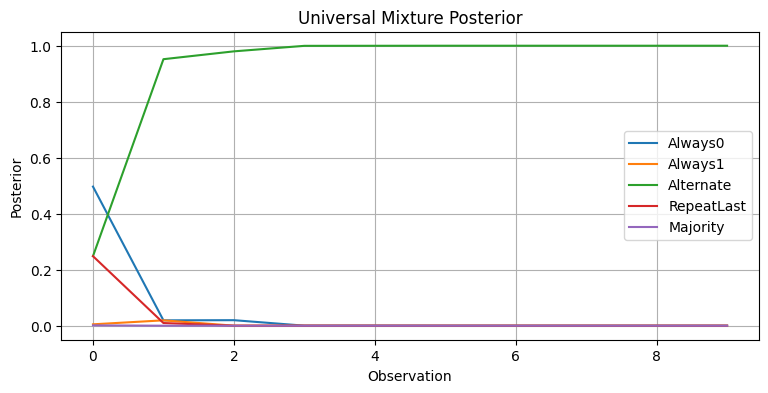

In [8]:
beliefs=np.array(beliefs)

plt.figure(figsize=(9,4))
for i,h in enumerate(hypotheses):
    plt.plot(beliefs[:,i],label=h.name)

plt.legend()
plt.grid()
plt.xlabel("Observation")
plt.ylabel("Posterior")
plt.title("Universal Mixture Posterior")
plt.show()


## Bayesian Model Averaging

In [9]:
history=[0,1,0,1]

mix=UniversalMixture(hypotheses)

for x in history:
    mix.update(history[:history.index(x)],x)

print("Posterior")

for h,p in zip(hypotheses,mix.posterior):
    print(h.name,round(p,4))

p0,p1=mix.predict_probability(history)

print("\nCombined Prediction")
print("P(next=0)",round(p0,3))
print("P(next=1)",round(p1,3))


Posterior
Always0 0.0002
Always1 0.0002
Alternate 0.9995
RepeatLast 0.0001
Majority 0.0

Combined Prediction
P(next=0) 1.0
P(next=1) 0.0


# Discussion

Notebook 1 selected actions using a planner.

Notebook 2 replaces a single world model with a **mixture of competing models**.

Instead of asking:

> Which hypothesis is correct?

we ask:

> What is the weighted prediction across all hypotheses?

This is the central intuition behind Solomonoff induction, although the real
theory considers all computable programs rather than a finite list.

## Next Notebook

Notebook 3 introduces:

- Expectimax search
- Monte Carlo rollouts
- Multi-step planning
- Exploration vs exploitation
- Discounted future rewards
